# Targeted attack success experiments

Questo notebook estende `targeted_attacks.ipynb` con un obiettivo piu' misurabile: forzare un segnale BUY o SELL in uno specifico timestep. L'idea e' separare il successo dell'attacco dal solo risultato finale del backtest, misurando direttamente se l'ATS emette il segnale voluto sotto diverse condizioni.

Domande sperimentali:

- quanto spesso un attacco riesce a forzare BUY/SELL in un timestep scelto?
- cambia il tasso di successo al variare di asset, strategia o modello ML?
- quanto e' grande la perturbazione minima necessaria?
- il timing dell'attacco influenza l'Attack Success Rate?

Convenzione importante: `attack_day` e' l'indice della serie di segnali prodotta dalla strategia. Le strategie gia' presenti nel progetto usano finestre mobili e shift anti-lookahead, quindi il successo viene valutato sul segnale operativo finale, non direttamente sul valore predetto.

In [1]:
import sys
from pathlib import Path
sys.path.append('../scr')


from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

from trade.trading_strategy import moving_average_strategy, rolling_std_deviation_strategy, rate_of_change_strategy
from trade.backtest import simulate_trades_with_allocation
from utils import calculate_cumulative_returns, preprocess_data

SCR_PATH = Path('../scr').resolve()
PROJECT_ROOT = SCR_PATH.parent
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
DEFAULT_MODEL_FOLDER = NOTEBOOK_DIR / "models"
RESULTS_DIR = NOTEBOOK_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

FEATURES = ["high", "low", "open", "close", "volume"]
CLOSE_FEATURE_INDEX = FEATURES.index("close")

tickers = ['GOOGL', 'AMZN', 'AAPL', 'PEP', 'JNJ', 'PFE', 'MRK', 'ABBV', 'PG', 'KO',
           'WMT', 'JPM', 'BAC', 'GS', 'V', 'XOM', 'CVX', 'COP', 'BP', 'BA',
           'MMM', 'HON', 'GE', 'T', 'VZ', 'TMUS', 'HSY', 'DUK', 'SO', 'EXC', 'AEP',
           'AMT', 'PLD', 'SPG', 'BHP', 'RIO', 'VALE', 'FCX']
start_date = '2010-01-01'
end_date = '2023-10-23'
sequence_length = 50
window_sizes = [50, 40, 30]

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Helper per dati, modelli e metriche

Le funzioni sotto riusano `preprocess_data` e `calculate_cumulative_returns` da `notebooks/utils.py`. `preprocess_data` ora supporta anche `source="csv"`, quindi il notebook legge i dati locali senza scaricarli da `yfinance`. Nel notebook restano solo i wrapper necessari all'esperimento targeted: cache dei modelli/predizioni e predizione con `X_override` dopo la perturbazione.


In [2]:
def preprocess_ticker_from_csv(ticker, sequence_length = 50):
    result = preprocess_data(
        ticker,
        start_date=None,
        end_date=None,
        sequence_length=sequence_length,
        source="csv",
        data_folder=str(PROJECT_ROOT / "data"),
    )
    if result is None:
        raise FileNotFoundError(f"Missing CSV data for {ticker}")

    _, _, X_test, y_test, y_min, y_max, _, _ = result
    y_range = y_max - y_min if y_max != y_min else 1.0

    return {
        "X_test": X_test,
        "y_test": y_test,
        "y_actual": y_test * y_range + y_min,
        "y_min": y_min,
        "y_max": y_max,
        "y_range": y_range,
    }


_DATA_CACHE = {}
_MODEL_CACHE = {}
_PREDICTION_CACHE = {}


def get_ticker_data(ticker, sequence_length = 50):
    key = (ticker, sequence_length)
    if key not in _DATA_CACHE:
        _DATA_CACHE[key] = preprocess_ticker_from_csv(ticker, sequence_length)
    return _DATA_CACHE[key]


def get_model(ticker, model_folder = DEFAULT_MODEL_FOLDER):
    model_path = Path(model_folder) / f"{ticker}_model.h5"
    if not model_path.exists():
        raise FileNotFoundError(f"Missing model for {ticker}: {model_path}")

    key = (str(model_path.resolve()), ticker)
    if key not in _MODEL_CACHE:
        _MODEL_CACHE[key] = load_model(model_path, compile=False)
    return _MODEL_CACHE[key]


def predict_ticker(ticker, model_folder = DEFAULT_MODEL_FOLDER, sequence_length = 50, X_override = None):
    data = get_ticker_data(ticker, sequence_length)
    X = data["X_test"] if X_override is None else X_override
    model = get_model(ticker, model_folder)
    pred_norm = model.predict(X, verbose=0).reshape(-1)
    return pred_norm * data["y_range"] + data["y_min"]


def get_predictions_and_actuals(tickers, model_folder = DEFAULT_MODEL_FOLDER, sequence_length = 50):
    tickers = tuple(tickers)
    key = (tickers, str(Path(model_folder).resolve()), sequence_length)
    if key in _PREDICTION_CACHE:
        return _PREDICTION_CACHE[key]

    predictions = {}
    actuals = {}
    for ticker in tickers:
        predictions[ticker] = predict_ticker(ticker, model_folder, sequence_length)
        actuals[ticker] = get_ticker_data(ticker, sequence_length)["y_actual"]

    _PREDICTION_CACHE[key] = (predictions, actuals)
    return predictions, actuals


def final_cumulative_return(returns):
    if len(returns) == 0:
        return np.nan
    return float(calculate_cumulative_returns(returns)[-1])

## Definizione degli ATS setup

Uno setup ATS e' qui definito come combinazione di:

- insieme di asset tradati;
- strategia che trasforma le predizioni in segnali;
- cartella dei modelli ML.

Nel repository e' disponibile una famiglia di modelli LSTM in `notebooks/models`. Se in seguito alleni modelli alternativi, puoi aggiungere altre cartelle in `MODEL_FOLDERS` e riusare le stesse funzioni senza cambiare la metrica.

In [3]:
STRATEGIES = {
    "MA": lambda predictions, actuals: moving_average_strategy(
        predictions, short_window=5, long_window=20, threshold=0.01
    ),
    "BB": lambda predictions, actuals: rolling_std_deviation_strategy(
        predictions, actuals, window=20, num_std_dev=2
    ),
    "ROC": lambda predictions, actuals: rate_of_change_strategy(
        predictions, window=14, threshold=0.01
    ),
}

MODEL_FOLDERS = {
    "LSTM": DEFAULT_MODEL_FOLDER,
    # For future comparisons:
    # "LSTM_SHORT": NOTEBOOK_DIR / "models_lstm_short",
    # "GRU": NOTEBOOK_DIR / "models_gru",
}


@dataclass
class ATSSetup:
    name: str
    tickers: Tuple[str, ...]
    strategy_name: str
    model_name: str = "LSTM"
    attacked_ticker: str = "GOOGL"

    @property
    def strategy(self):
        return STRATEGIES[self.strategy_name]

    @property
    def model_folder(self):
        return MODEL_FOLDERS[self.model_name]


SETUPS = [
    ATSSetup("LSTM_All_MA", tuple(tickers), "MA", attacked_ticker="GOOGL"),
    #ATSSetup("LSTM_All_ROC", tuple(tickers), "ROC", attacked_ticker="GOOGL"),
    #ATSSetup("LSTM_All_ROC", tuple(tickers), "BB", attacked_ticker="GOOGL"),
    #ATSSetup("LSTM_GOOGL_MA", ("GOOGL",), "MA", attacked_ticker="GOOGL"),
    #ATSSetup("LSTM_Tech3_MA", ("GOOGL", "AAPL", "AMZN"), "MA", attacked_ticker="GOOGL"),
    #ATSSetup("LSTM_Defensive_MA", ("JNJ", "PG", "KO"), "MA", attacked_ticker="JNJ"),
    #ATSSetup("LSTM_Tech3_BB", ("GOOGL", "AAPL", "AMZN"), "BB", attacked_ticker="GOOGL"),
    #ATSSetup("LSTM_Tech3_ROC", ("GOOGL", "AAPL", "AMZN"), "ROC", attacked_ticker="GOOGL"),
]

SIGNAL_LABELS = {-1: "SELL", 0: "HOLD", 1: "BUY"}
TARGET_SIGNALS = {"force_buy": 1, "force_sell": -1}

pd.DataFrame([
    {
        "setup": setup.name,
        "model": setup.model_name,
        "strategy": setup.strategy_name,
        "assets": ", ".join(setup.tickers),
        "attacked_ticker": setup.attacked_ticker,
    }
    for setup in SETUPS
])

,setup,model,strategy,assets,attacked_ticker
0,LSTM_All_MA,LSTM,MA,"GOOGL, AMZN, AAPL, PEP, JNJ, PFE, MRK, ABBV, P...",GOOGL


## Obiettivo targeted e attacco

Per ogni tuple `(setup, attacked_ticker, attack_day, target_signal)` l'attaccante modifica solo l'ultimo valore normalizzato di `close` nella finestra di input del giorno attaccato. La ricerca prova perturbazioni positive e negative ordinate per ampiezza e registra la prima che fa emettere il segnale target dalla strategia.

Metriche principali:

- `success`: 1 se il segnale attaccato coincide con BUY/SELL target;
- `attack_success_rate`: media di `success` su giorni e setup;
- `min_abs_delta_norm`: minima perturbazione normalizzata necessaria;
- `prediction_shift`: variazione della predizione sul ticker attaccato;
- `delta_final_cr`: variazione del cumulative return finale, usata solo come metrica di supporto.

In [4]:
def make_delta_grid(max_abs_delta = 0.35, steps = 35):
    '''Build perturbations in increasing absolute size, testing both directions'''
    magnitudes = np.linspace(0, max_abs_delta, steps + 1)
    deltas = [0.0]
    for magnitude in magnitudes[1:]:
        deltas.extend([float(magnitude), float(-magnitude)])
    return deltas


def signal_at(signals, ticker, attack_day):
    '''Return the trading signal for one ticker/day, or None if unavailable'''
    ticker_signals = signals.get(ticker)
    if ticker_signals is None or attack_day < 0 or attack_day >= len(ticker_signals):
        return None
    return int(ticker_signals[attack_day])



def evaluate_targeted_attack(setup, attack_day, target_signal, sequence_length = 50, max_abs_delta = 0.35, steps = 35):
    ''' Evaluate one targeted attack by searching for a perturbation that forces the target signal'''
    # Build the clean ATS baseline
    predictions_base, actuals = get_predictions_and_actuals(
        setup.tickers, setup.model_folder, sequence_length
    )
    signals_base = setup.strategy(predictions_base, actuals)
    baseline_signal = signal_at(signals_base, setup.attacked_ticker, attack_day)

    # Skip invalid attack days
    if baseline_signal is None:
        return {
            "setup": setup.name,
            "model": setup.model_name,
            "strategy": setup.strategy_name,
            "assets": ",".join(setup.tickers),
            "attacked_ticker": setup.attacked_ticker,
            "attack_day": attack_day,
            "target_signal": target_signal,
            "target_label": SIGNAL_LABELS[target_signal],
            "baseline_signal": np.nan,
            "baseline_label": "NA",
            "attacked_signal": np.nan,
            "attacked_label": "NA",
            "success": False,
            "already_target": False,
            "min_delta_norm": np.nan,
            "min_abs_delta_norm": np.nan,
            "prediction_shift": np.nan,
            "delta_final_cr": np.nan,
            "valid": False,
        }

    baseline_returns = simulate_trades_with_allocation(predictions_base, actuals, signals_base)
    baseline_final_cr = final_cumulative_return(baseline_returns)

    data = get_ticker_data(setup.attacked_ticker, sequence_length)
    X_original = data["X_test"]
    baseline_attacked_pred = predictions_base[setup.attacked_ticker]

    best = None
    # Search the smallest perturbation that reaches the target signal
    for delta in make_delta_grid(max_abs_delta=max_abs_delta, steps=steps):
        attacked_X = X_original.copy()
        # Perturb only the last "close" value of the attacked input window
        attacked_X[attack_day, -1, CLOSE_FEATURE_INDEX] = np.clip(
            attacked_X[attack_day, -1, CLOSE_FEATURE_INDEX] + delta,
            0.0,
            1.0,
        )

        attacked_ticker_prediction = predict_ticker(
            setup.attacked_ticker,
            setup.model_folder,
            sequence_length,
            X_override=attacked_X,
        )

        predictions_attack = {ticker: values.copy() for ticker, values in predictions_base.items()}
        predictions_attack[setup.attacked_ticker] = attacked_ticker_prediction[:len(baseline_attacked_pred)]

        # Recompute the trading decision after the attacked prediction
        signals_attack = setup.strategy(predictions_attack, actuals)
        attacked_signal = signal_at(signals_attack, setup.attacked_ticker, attack_day)

        if attacked_signal == target_signal:
            # Store the first successful delta
            attacked_returns = simulate_trades_with_allocation(predictions_attack, actuals, signals_attack)
            attacked_final_cr = final_cumulative_return(attacked_returns)
            best = {
                "attacked_signal": attacked_signal,
                "min_delta_norm": delta,
                "min_abs_delta_norm": abs(delta),
                "prediction_shift": float(
                    predictions_attack[setup.attacked_ticker][attack_day]
                    - baseline_attacked_pred[attack_day]
                ),
                "delta_final_cr": attacked_final_cr - baseline_final_cr,
            }
            break

    if best is None:
        # No tested perturbation reached the requested target.
        best = {
            "attacked_signal": np.nan,
            "min_delta_norm": np.nan,
            "min_abs_delta_norm": np.nan,
            "prediction_shift": np.nan,
            "delta_final_cr": np.nan,
        }

    attacked_signal = best["attacked_signal"]
    return {
        "setup": setup.name,
        "model": setup.model_name,
        "strategy": setup.strategy_name,
        "assets": ",".join(setup.tickers),
        "attacked_ticker": setup.attacked_ticker,
        "attack_day": attack_day,
        "target_signal": target_signal,
        "target_label": SIGNAL_LABELS[target_signal],
        "baseline_signal": baseline_signal,
        "baseline_label": SIGNAL_LABELS.get(baseline_signal, "NA"),
        "attacked_signal": attacked_signal,
        "attacked_label": SIGNAL_LABELS.get(attacked_signal, "NA"),
        "success": attacked_signal == target_signal,
        "already_target": baseline_signal == target_signal,
        "valid": True,
        **best,
    }


def run_targeted_attack_experiment(
    setups,
    attack_days,
    target_signals = TARGET_SIGNALS,
    sequence_length = 50,
    max_abs_delta = 0.35,
    steps = 35,
    timing_policy = "manual",
):
    rows = []
    attack_days = list(attack_days)
    total = len(setups) * len(attack_days) * len(target_signals)
    done = 0

    for setup in setups:
        for attack_day in attack_days:
            for objective_name, target_signal in target_signals.items():
                row = evaluate_targeted_attack(
                    setup=setup,
                    attack_day=int(attack_day),
                    target_signal=target_signal,
                    sequence_length=sequence_length,
                    max_abs_delta=max_abs_delta,
                    steps=steps,
                )
                row["objective"] = objective_name
                row["timing_policy"] = timing_policy
                rows.append(row)
                done += 1
                if done % 5 == 0 or done == total:
                    print(f"completed {done}/{total} trials")

    return pd.DataFrame(rows)

## Selezione dinamica degli attack days

Invece di usare solo giorni fissi, definiamo policy di timing basate su informazioni osservabili nel test set. Questo permette di confrontare l'ASR in condizioni diverse:

- `uniform`: baseline con giorni distribuiti lungo il periodo;
- `high_volatility`: giorni con alta volatilita' rolling dei prezzi reali;
- `high_pred_volatility`: giorni con alta volatilita' rolling delle predizioni;
- `strong_trend`: giorni con momentum assoluto elevato;
- `near_ma_boundary`: giorni in cui la strategia Moving Average e' vicina alla soglia decisionale, quindi il segnale e' potenzialmente piu' fragile.

Le metriche sono calcolate usando finestre rolling e valori disponibili fino al giorno considerato. Per `near_ma_boundary` usiamo lo stato dell'ATS baseline, quindi e' una policy attacker-aware: utile per capire quanto il successo dipenda dalla vicinanza alla decision boundary.


In [5]:
def _rolling_std(values, window):
    series = pd.Series(values)
    return series.rolling(window=window, min_periods=window).std().to_numpy()


def _rate_of_change(values, window):
    roc = np.full(len(values), np.nan)
    if len(values) > window:
        denominator = np.where(values[:-window] == 0, np.nan, values[:-window])
        roc[window:] = (values[window:] - values[:-window]) / denominator
    return roc


def _ma_decision_boundary_distance(predictions, short_window = 5, long_window = 20, threshold = 0.01):
    """Distance from the closest MA decision threshold for each signal index"""
    distance = np.full(len(predictions), np.nan)
    if len(predictions) < long_window:
        return distance

    short_mavg = np.convolve(predictions, np.ones(short_window), "valid") / short_window
    long_mavg = np.convolve(predictions, np.ones(long_window), "valid") / long_window
    mavg_diff = short_mavg[long_window - short_window:] - long_mavg

    shifted_distance = np.minimum(
        np.abs(mavg_diff - threshold),
        np.abs(mavg_diff + threshold),
    )
    shifted_distance = np.pad(shifted_distance, (1, 0), "constant", constant_values=np.nan)[:-1]
    distance[:len(shifted_distance)] = shifted_distance
    return distance



def candidate_attack_days(setup, sequence_length = 50, min_day = 30, max_day = None):
    '''Return the valid day indices that can be considered for launching an attack'''
    predictions, actuals = get_predictions_and_actuals(setup.tickers, setup.model_folder, sequence_length)
    signals = setup.strategy(predictions, actuals)
    signal_len = len(signals[setup.attacked_ticker])
    pred_len = len(predictions[setup.attacked_ticker])
    upper = min(signal_len, pred_len)
    if max_day is not None:
        upper = min(upper, max_day)
    return np.arange(min_day, upper)



def timing_scores_for_setup(setup, sequence_length = 50, volatility_window = 20, trend_window = 20, min_day = 30, max_day = None):
    '''Compute timing-related metrics used to rank candidate attack days for one setup'''
    predictions, actuals = get_predictions_and_actuals(setup.tickers, setup.model_folder, sequence_length)
    ticker = setup.attacked_ticker
    days = candidate_attack_days(setup, sequence_length, min_day=min_day, max_day=max_day)

    actual = actuals[ticker]
    pred = predictions[ticker]

    scores = pd.DataFrame({"attack_day": days})
    scores["actual_volatility"] = _rolling_std(actual, volatility_window)[days]
    scores["prediction_volatility"] = _rolling_std(pred, volatility_window)[days]
    scores["abs_trend"] = np.abs(_rate_of_change(actual, trend_window)[days])
    scores["ma_boundary_distance"] = _ma_decision_boundary_distance(pred)[days]
    scores["baseline_signal"] = setup.strategy(predictions, actuals)[ticker][days]
    return scores


def select_attack_days_by_policy(setup, policy, n_days = 12, sequence_length = 50, min_day = 30, max_day = None):
    '''Select attack days according to the requested timing policy and ranking criterion'''
    scores = timing_scores_for_setup(setup, sequence_length=sequence_length, min_day=min_day, max_day=max_day)

    if policy == "uniform":
        candidates = scores["attack_day"].to_numpy()
        positions = np.linspace(0, len(candidates) - 1, n_days).round().astype(int)
        return candidates[positions]

    score_columns = {
        "high_volatility": ("actual_volatility", False),
        "high_pred_volatility": ("prediction_volatility", False),
        "strong_trend": ("abs_trend", False),
        "near_ma_boundary": ("ma_boundary_distance", True),
    }
    if policy not in score_columns:
        raise ValueError(f"Unknown timing policy: {policy}")

    column, ascending = score_columns[policy]
    selected = (
        scores.dropna(subset=[column])
        .sort_values(column, ascending=ascending)
        .head(n_days)
        .sort_values("attack_day")
    )
    return selected["attack_day"].to_numpy(dtype=int)



def build_attack_day_plan(setups: List[ATSSetup], policies: Iterable[str], n_days: int = 12, sequence_length: int = 50, min_day: int = 30, max_day: Optional[int] = None):
    '''Build a mapping from each setup-policy pair to its selected attack days'''
    plan = {}
    for setup in setups:
        for policy in policies:
            plan[(setup.name, policy)] = select_attack_days_by_policy(
                setup,
                policy=policy,
                n_days=n_days,
                sequence_length=sequence_length,
                min_day=min_day,
                max_day=max_day,
            )
    return plan


## Esecuzione dell'esperimento

La cella seguente costruisce un piano di attack days per ogni setup e policy di timing. `uniform` sostituisce i vecchi giorni fissi come baseline; le altre policy scelgono dinamicamente i giorni piu' interessanti secondo volatilita', trend o vicinanza alla soglia decisionale.


In [6]:
SEQUENCE_LENGTH = 50
N_ATTACK_DAYS = 12
TIMING_POLICIES = [
    "uniform",
    "high_volatility",
    "high_pred_volatility",
    "strong_trend",
    "near_ma_boundary",
]
MAX_ABS_DELTA = 0.35
GRID_STEPS = 35

attack_day_plan = build_attack_day_plan(setups=SETUPS, policies=TIMING_POLICIES, n_days=N_ATTACK_DAYS, sequence_length=SEQUENCE_LENGTH, min_day=30)

pd.DataFrame([
    {"setup": setup_name, "timing_policy": policy, "attack_days": days.tolist()}
    for (setup_name, policy), days in attack_day_plan.items()
])


Metal device set to: Apple M1

systemMemory: 8,00 GB
maxCacheSize: 2,67 GB



,setup,timing_policy,attack_days
0,LSTM_All_MA,uniform,"[30, 88, 145, 203, 261, 319, 376, 434, 492, 55..."
1,LSTM_All_MA,high_volatility,"[310, 311, 312, 313, 314, 315, 579, 580, 581, ..."
2,LSTM_All_MA,high_pred_volatility,"[312, 313, 314, 315, 316, 317, 581, 582, 583, ..."
3,LSTM_All_MA,strong_trend,"[311, 313, 463, 504, 505, 507, 539, 579, 580, ..."
4,LSTM_All_MA,near_ma_boundary,"[142, 205, 217, 415, 474, 495, 515, 516, 551, ..."


In [7]:
results_path = RESULTS_DIR / "targeted_attack_success_results.csv"

result_frames = []
for setup in SETUPS:
    for policy in TIMING_POLICIES:
        days = attack_day_plan[(setup.name, policy)]
        print(f"Running {setup.name} / {policy}: {days.tolist()}")
        result_frames.append(
            run_targeted_attack_experiment(
                setups=[setup],
                attack_days=days,
                target_signals=TARGET_SIGNALS,
                sequence_length=SEQUENCE_LENGTH,
                max_abs_delta=MAX_ABS_DELTA,
                steps=GRID_STEPS,
                timing_policy=policy,
            )
        )

results = pd.concat(result_frames, ignore_index=True)
results.to_csv(results_path, index=False)
print(f"Saved: {results_path}")
results.head(10)


Running LSTM_All_MA / uniform: [30, 88, 145, 203, 261, 319, 376, 434, 492, 550, 607, 665]
completed 5/24 trials
completed 10/24 trials
completed 15/24 trials
completed 20/24 trials
completed 24/24 trials
Running LSTM_All_MA / high_volatility: [310, 311, 312, 313, 314, 315, 579, 580, 581, 582, 583, 584]
completed 5/24 trials
completed 10/24 trials
completed 15/24 trials
completed 20/24 trials
completed 24/24 trials
Running LSTM_All_MA / high_pred_volatility: [312, 313, 314, 315, 316, 317, 581, 582, 583, 584, 585, 586]
completed 5/24 trials
completed 10/24 trials
completed 15/24 trials
completed 20/24 trials
completed 24/24 trials
Running LSTM_All_MA / strong_trend: [311, 313, 463, 504, 505, 507, 539, 579, 580, 587, 588, 589]
completed 5/24 trials
completed 10/24 trials
completed 15/24 trials
completed 20/24 trials
completed 24/24 trials
Running LSTM_All_MA / near_ma_boundary: [142, 205, 217, 415, 474, 495, 515, 516, 551, 552, 553, 578]
completed 5/24 trials
completed 10/24 trials
comple

,setup,model,strategy,assets,attacked_ticker,attack_day,target_signal,target_label,baseline_signal,baseline_label,...,attacked_label,success,already_target,valid,min_delta_norm,min_abs_delta_norm,prediction_shift,delta_final_cr,objective,timing_policy
0,LSTM_All_MA,LSTM,MA,"GOOGL,AMZN,AAPL,PEP,JNJ,PFE,MRK,ABBV,PG,KO,WMT...",GOOGL,30,1,BUY,1,BUY,...,BUY,True,True,True,0.0,0.0,0.000000,0.000000,force_buy,uniform
1,LSTM_All_MA,LSTM,MA,"GOOGL,AMZN,AAPL,PEP,JNJ,PFE,MRK,ABBV,PG,KO,WMT...",GOOGL,30,-1,SELL,1,BUY,...,NA,False,False,True,NaN,NaN,NaN,NaN,force_sell,uniform
2,LSTM_All_MA,LSTM,MA,"GOOGL,AMZN,AAPL,PEP,JNJ,PFE,MRK,ABBV,PG,KO,WMT...",GOOGL,88,1,BUY,1,BUY,...,BUY,True,True,True,0.0,0.0,0.000000,0.000000,force_buy,uniform
3,LSTM_All_MA,LSTM,MA,"GOOGL,AMZN,AAPL,PEP,JNJ,PFE,MRK,ABBV,PG,KO,WMT...",GOOGL,88,-1,SELL,1,BUY,...,SELL,True,False,True,0.2,0.2,13.346642,-1.997208,force_sell,uniform
4,LSTM_All_MA,LSTM,MA,"GOOGL,AMZN,AAPL,PEP,JNJ,PFE,MRK,ABBV,PG,KO,WMT...",GOOGL,145,1,BUY,-1,SELL,...,NA,False,False,True,NaN,NaN,NaN,NaN,force_buy,uniform
5,LSTM_All_MA,LSTM,MA,"GOOGL,AMZN,AAPL,PEP,JNJ,PFE,MRK,ABBV,PG,KO,WMT...",GOOGL,145,-1,SELL,-1,SELL,...,SELL,True,True,True,0.0,0.0,0.000000,0.000000,force_sell,uniform
6,LSTM_All_MA,LSTM,MA,"GOOGL,AMZN,AAPL,PEP,JNJ,PFE,MRK,ABBV,PG,KO,WMT...",GOOGL,203,1,BUY,1,BUY,...,BUY,True,True,True,0.0,0.0,0.000000,0.000000,force_buy,uniform
7,LSTM_All_MA,LSTM,MA,"GOOGL,AMZN,AAPL,PEP,JNJ,PFE,MRK,ABBV,PG,KO,WMT...",GOOGL,203,-1,SELL,1,BUY,...,NA,False,False,True,NaN,NaN,NaN,NaN,force_sell,uniform
8,LSTM_All_MA,LSTM,MA,"GOOGL,AMZN,AAPL,PEP,JNJ,PFE,MRK,ABBV,PG,KO,WMT...",GOOGL,261,1,BUY,-1,SELL,...,NA,False,False,True,NaN,NaN,NaN,NaN,force_buy,uniform
9,LSTM_All_MA,LSTM,MA,"GOOGL,AMZN,AAPL,PEP,JNJ,PFE,MRK,ABBV,PG,KO,WMT...",GOOGL,261,-1,SELL,-1,SELL,...,SELL,True,True,True,0.0,0.0,0.000000,0.000000,force_sell,uniform


## Attack Success Rate per setup

Questa tabella e' il cuore dell'estensione: confronta setup ATS diversi usando una metrica direttamente legata all'obiettivo dell'attaccante.

In [8]:
# If you already ran the experiment in a previous session, uncomment this line:
results = pd.read_csv(RESULTS_DIR / "targeted_attack_success_results.csv")

valid_results = results[results["valid"]].copy()
valid_results["success"] = valid_results["success"].astype(bool)
valid_results["already_target"] = valid_results["already_target"].astype(bool)
valid_results["nontrivial_success"] = valid_results["success"] & ~valid_results["already_target"]

summary_by_setup = (
    valid_results
    .groupby(["setup", "model", "strategy", "timing_policy", "objective"], as_index=False)
    .agg(
        trials=("success", "size"),
        attack_success_rate=("success", "mean"),
        baseline_target_rate=("already_target", "mean"),
        nontrivial_trials=("already_target", lambda x: int((~x).sum())),
        nontrivial_successes=("nontrivial_success", "sum"),
        mean_min_abs_delta_norm=("min_abs_delta_norm", "mean"),
        median_min_abs_delta_norm=("min_abs_delta_norm", "median"),
        mean_delta_final_cr=("delta_final_cr", "mean"),
    )
)
summary_by_setup["nontrivial_attack_success_rate"] = np.where(
    summary_by_setup["nontrivial_trials"] > 0,
    summary_by_setup["nontrivial_successes"] / summary_by_setup["nontrivial_trials"],
    np.nan,
)
summary_by_setup = summary_by_setup.sort_values(
    ["objective", "nontrivial_attack_success_rate", "attack_success_rate"],
    ascending=[True, False, False],
)

summary_by_setup


,setup,model,strategy,timing_policy,objective,trials,attack_success_rate,baseline_target_rate,nontrivial_trials,nontrivial_successes,mean_min_abs_delta_norm,median_min_abs_delta_norm,mean_delta_final_cr,nontrivial_attack_success_rate
4,LSTM_All_MA,LSTM,MA,near_ma_boundary,force_buy,12,1.000000,0.500000,6,6,0.012500,0.005,-0.289625,1.000000
2,LSTM_All_MA,LSTM,MA,high_volatility,force_buy,12,0.500000,0.250000,9,3,0.066667,0.045,-0.328332,0.333333
8,LSTM_All_MA,LSTM,MA,uniform,force_buy,12,0.666667,0.583333,5,1,0.018750,0.000,0.002406,0.200000
0,LSTM_All_MA,LSTM,MA,high_pred_volatility,force_buy,12,0.333333,0.166667,10,2,0.077500,0.070,-0.497012,0.200000
6,LSTM_All_MA,LSTM,MA,strong_trend,force_buy,12,0.250000,0.166667,10,1,0.030000,0.000,0.006020,0.100000
1,LSTM_All_MA,LSTM,MA,high_pred_volatility,force_sell,12,1.000000,0.833333,2,2,0.011667,0.000,-0.163061,1.000000
3,LSTM_All_MA,LSTM,MA,high_volatility,force_sell,12,1.000000,0.750000,3,3,0.015833,0.000,-0.244592,1.000000
5,LSTM_All_MA,LSTM,MA,near_ma_boundary,force_sell,12,1.000000,0.333333,8,8,0.015000,0.010,-0.153718,1.000000
7,LSTM_All_MA,LSTM,MA,strong_trend,force_sell,12,0.916667,0.833333,2,1,0.004545,0.000,-0.088943,0.500000
9,LSTM_All_MA,LSTM,MA,uniform,force_sell,12,0.583333,0.416667,7,2,0.055714,0.000,-0.201016,0.285714


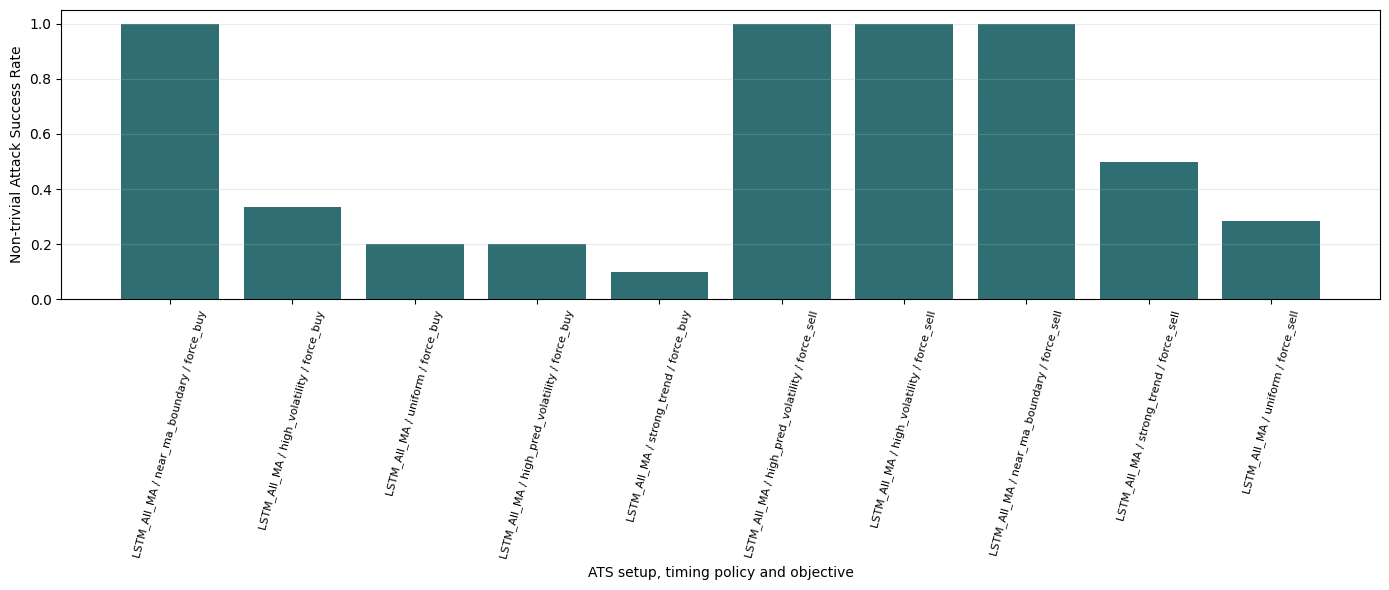

In [9]:
plot_data = summary_by_setup.copy()
plot_data["label"] = plot_data["setup"] + " / " + plot_data["timing_policy"] + " / " + plot_data["objective"]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(plot_data["label"], plot_data["nontrivial_attack_success_rate"], color="#2f6f73")
ax.set_ylabel("Non-trivial Attack Success Rate")
ax.set_xlabel("ATS setup, timing policy and objective")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=75, labelsize=8)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## Effetto del timing

Qui confrontiamo direttamente le policy di selezione del timing. La metrica piu' importante e' `nontrivial_attack_success_rate`, cioe' il successo calcolato sui soli casi in cui il segnale baseline non era gia' quello target.


In [10]:
timing_summary = (
    valid_results
    .groupby(["timing_policy", "attack_day"], as_index=False)
    .agg(
        attack_success_rate=("success", "mean"),
        nontrivial_attack_success_rate=("nontrivial_success", "mean"),
        baseline_target_rate=("already_target", "mean"),
        mean_min_abs_delta_norm=("min_abs_delta_norm", "mean"),
        mean_abs_prediction_shift=("prediction_shift", lambda x: np.nanmean(np.abs(x))),
        trials=("success", "size"),
    )
)

policy_summary = (
    valid_results
    .groupby("timing_policy", as_index=False)
    .agg(
        trials=("success", "size"),
        attack_success_rate=("success", "mean"),
        baseline_target_rate=("already_target", "mean"),
        nontrivial_trials=("already_target", lambda x: int((~x).sum())),
        nontrivial_successes=("nontrivial_success", "sum"),
        mean_min_abs_delta_norm=("min_abs_delta_norm", "mean"),
    )
)
policy_summary["nontrivial_attack_success_rate"] = np.where(
    policy_summary["nontrivial_trials"] > 0,
    policy_summary["nontrivial_successes"] / policy_summary["nontrivial_trials"],
    np.nan,
)
policy_summary.sort_values("nontrivial_attack_success_rate", ascending=False)


,timing_policy,trials,attack_success_rate,baseline_target_rate,nontrivial_trials,nontrivial_successes,mean_min_abs_delta_norm,nontrivial_attack_success_rate
2,near_ma_boundary,24,1.000000,0.416667,14,14,0.013750,1.000000
1,high_volatility,24,0.750000,0.500000,12,6,0.032778,0.500000
0,high_pred_volatility,24,0.666667,0.500000,12,4,0.028125,0.333333
4,uniform,24,0.625000,0.500000,12,3,0.036000,0.250000
3,strong_trend,24,0.583333,0.500000,12,2,0.010000,0.166667


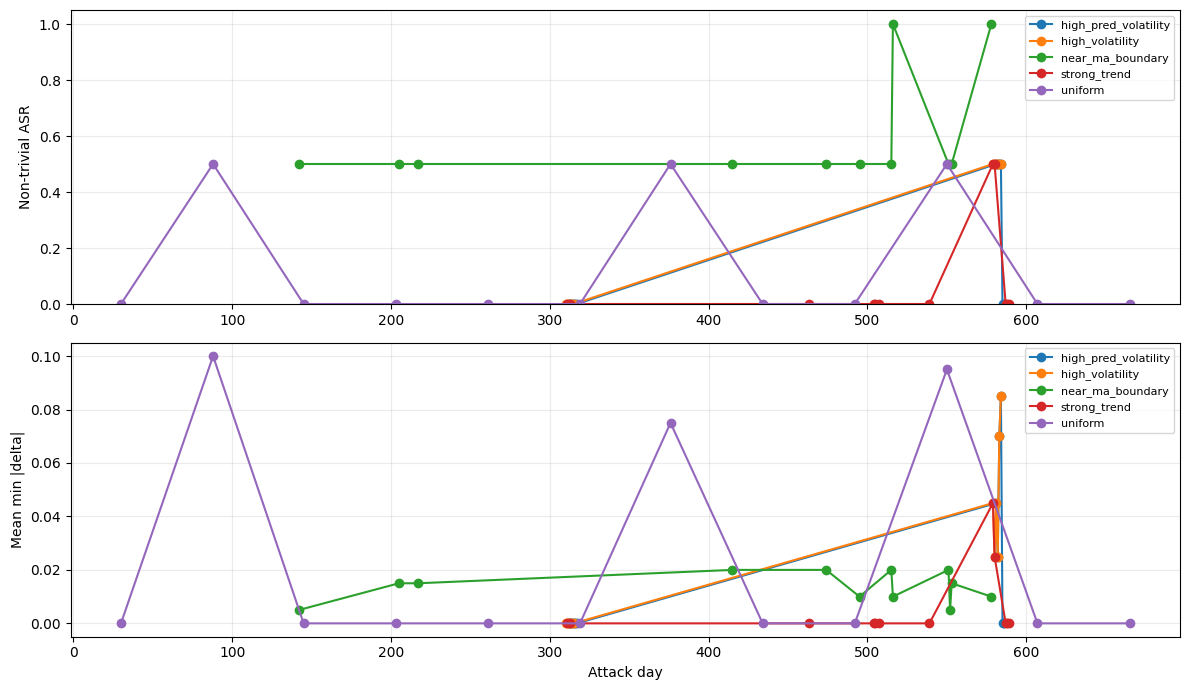

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

for policy, group in timing_summary.groupby("timing_policy"):
    group = group.sort_values("attack_day")
    axes[0].plot(group["attack_day"], group["nontrivial_attack_success_rate"], marker="o", label=policy)
    axes[1].plot(group["attack_day"], group["mean_min_abs_delta_norm"], marker="o", label=policy)

axes[0].set_ylabel("Non-trivial ASR")
axes[0].set_ylim(0, 1.05)
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].set_ylabel("Mean min |delta|")
axes[1].set_xlabel("Attack day")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Lettura per la tesi

Una possibile formulazione sperimentale e':

- **Objective**: given an ATS setup and a timestep `t`, force the trading strategy to output a target action `a*` in `{BUY, SELL}` for the attacked asset.
- **Success metric**: `ASR = successful targeted attacks / attempted targeted attacks`.
- **Cost metric**: minimum normalized perturbation required to reach the target signal.
- **Setup comparison**: vary strategy, traded asset universe and model folder.
- **Timing analysis**: estimate ASR as a function of the attacked timestep.

Questo permette di discutere robustezza e vulnerabilita' in modo piu' scientifico del solo confronto tra cumulative returns finali: il backtest rimane utile, ma come effetto economico secondario dopo aver misurato se l'attacco ha raggiunto il suo obiettivo operativo.